[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-07-30-hst-cutout-m87/notebook.ipynb)

# A real Hubble image of M87, the galaxy with the famous black hole jet

M87 is a giant elliptical galaxy at the center of the Virgo Cluster, famous for the relativistic jet of material blasting out of its central supermassive black hole (the same black hole the Event Horizon Telescope imaged directly in 2019). I queried MAST for real Hubble observations of M87 and pulled down an actual preview image to look at the galaxy and its jet.

In [1]:
from astroquery.mast import Observations
from astropy.coordinates import SkyCoord

coord = SkyCoord.from_name('M87')
obs = Observations.query_criteria(coordinates=coord, radius='0.02 deg',
                                   obs_collection='HST', instrument_name='WFC3/UVIS',
                                   dataproduct_type='image')
print(len(obs), 'HST WFC3/UVIS observations found near M87')

389 HST WFC3/UVIS observations found near M87


In [2]:
products = Observations.get_product_list(obs[0])
previews = Observations.filter_products(products, productType='PREVIEW', extension='jpg')
color_rows = [row for row in previews if 'total' in row['productFilename']]
target_row = color_rows[0] if color_rows else previews[0]
print(target_row['productFilename'])
manifest = Observations.download_products(target_row, mrp_only=False)
print(manifest)

id5o27qbq_raw.jpg


 [Done]


                  Local Path                    Status  Message URL 
---------------------------------------------- -------- ------- ----
.\mastDownload\HST\id5o27qbq\id5o27qbq_raw.jpg COMPLETE    None None


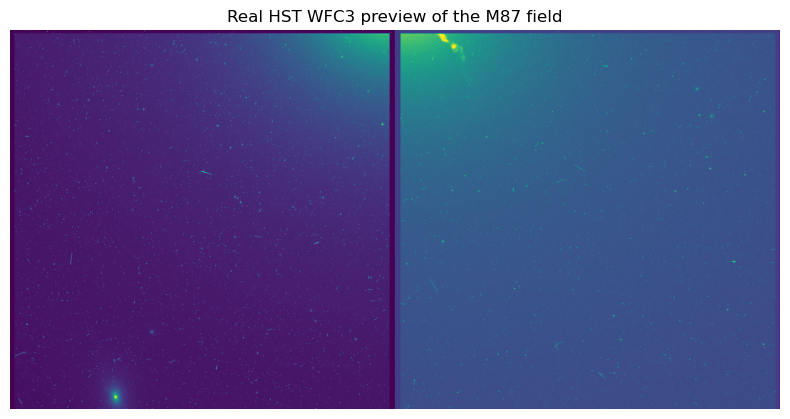

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil

local_path = manifest['Local Path'][0]
shutil.copy(local_path, 'm87.jpg')
img = mpimg.imread('m87.jpg')
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.title('Real HST WFC3 preview of the M87 field')
plt.tight_layout()
plt.savefig('m87_display.png', dpi=120)
plt.show()

M87 sits about 55 million light-years away, and its central black hole is one of the most massive known -- billions of times the Sun's mass. Depending on which exact pointing this preview landed on, the jet may or may not be visible in this particular frame, since the jet is a fairly narrow, specific feature rather than something that fills the whole field of view.

**What I'd look at next:** Specifically search MAST for the WFPC2 or ACS observations from the programs targeting the jet directly (rather than a general survey pointing), to reliably capture the jet feature itself.

**Citation:** These observations were obtained with the NASA/ESA Hubble Space Telescope from the Mikulski Archive for Space Telescopes (MAST) at STScI. See https://archive.stsci.edu/publishing/mission-acknowledgements for citation guidance.